# 1. Основне завдання (доробити)

Завантажте будь-яке кольорове фото (власне або з URL) і виконайте:

* **(а)** Відображте три канали BGR окремо.
* **(б)** Побудуйте гістограму по каналах і гістограму каналу V у HSV – порівняйте, що інформативніше.
* **(в)** Зробіть center crop і resize до 224×224, порахуйте розмір у MB для `uint8` і `float32`.

> **Підсумуйте:** що вам розповіла гістограма про це фото?

---

# 2. Додаткова практика (за бажанням)

* **Вимкніть один канал** (`img[:, :, 2] = 0`) і порівняйте результат з оригіналом.
* **Зміна контрасту:** спробуйте `alpha=0.5` (знижуємо контраст) і `alpha=2.0` (підвищуємо) в `convertScaleAbs` – що відбувається з деталями?
* **Додавання шуму:** додайте шум `sigma=10`, `25` і `50` – при якому значенні деталі ще розпізнаються?
* **Розрахунок пам'яті:** порахуйте пам'ять для 4K кадру (3840×2160×3) у `uint8` і `float32`.

Картинка успешно скачана по URL! Размер: (850, 1280, 3)


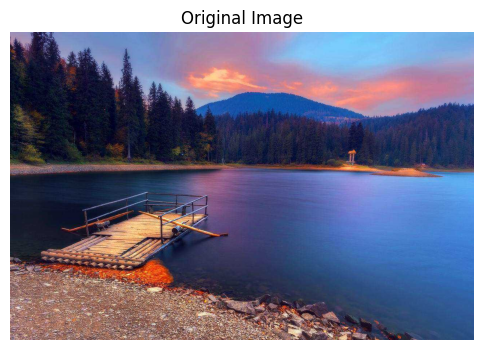

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
# 1. Наш юрл
url = 'https://karpaty.love/uploads/posts/2017-10/1508689396_1508686392_ozero-sinevir-3.jpg'
# 2. Маскування під браузер
req_headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}
req = urllib.request.Request(url, headers=req_headers)
# 3. Качаємо в пам'ять та переводимо в BGR
with urllib.request.urlopen(req) as response:
    arr = np.asarray(bytearray(response.read()), dtype=np.uint8)
    img_bgr = cv2.imdecode(arr, cv2.IMREAD_COLOR)

print("Картинка успешно скачана по URL! Размер:", img_bgr.shape)

# 4. Показуємо оригінальное фото (переводимо BGR -> RGB)
plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
plt.show()

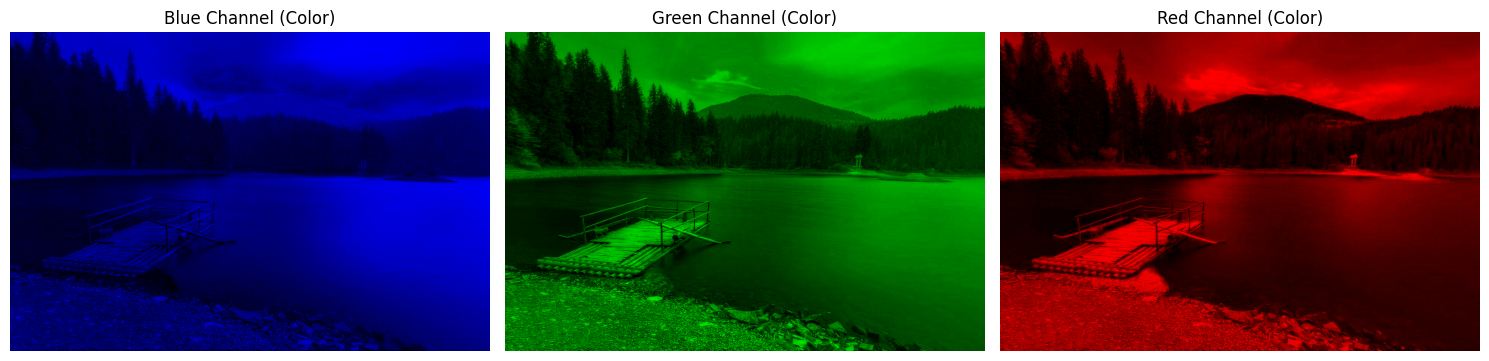

In [ ]:
# a) Відображте три канали BGR окремо
h, w = img_bgr.shape[:2]

# 1. Робимо заготовку з нулів
zeros = np.zeros((h, w), dtype=np.uint8)

# 2. Збираємо кольорові версії каналів (ставимо zeros на місця інших каналів)
#    Формат: BGR
blue_img  = cv2.merge([img_bgr[:, :, 0], zeros, zeros])
green_img = cv2.merge([zeros, img_bgr[:, :, 1], zeros])
red_img   = cv2.merge([zeros, zeros, img_bgr[:, :, 2]])

# 3. Візуалізація (Конвертація кольору, заголовок, вимкнення сітки координат)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(cv2.cvtColor(blue_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Blue Channel (Color)')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(green_img, cv2.COLOR_BGR2RGB))
axes[1].set_title('Green Channel (Color)')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(red_img, cv2.COLOR_BGR2RGB))
axes[2].set_title('Red Channel (Color)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

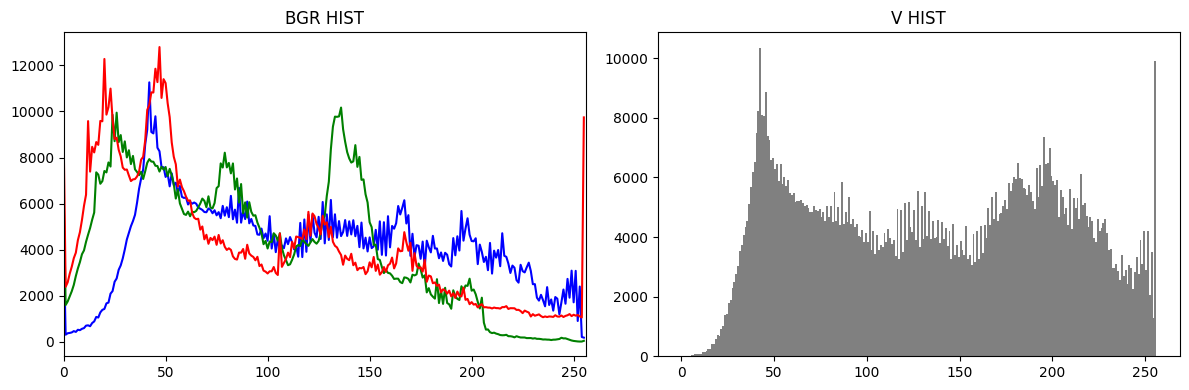

In [ ]:
# б) Побудуйте гістограму по каналах і гістограму каналу V у HSV – порівняйте що інформативніше
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
v_channel = img_hsv[:, :, 2]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# 1. Гістограма BGR
colors = ('b', 'g', 'r')
for i, col in enumerate(colors):
  hist = cv2.calcHist([img_bgr], [i], None, [256], [0, 256])
  axes[0].plot(hist, color=col)
axes[0].set_title('BGR HIST')
axes[0].set_xlim([0, 256])
# 2. Гістограма V
axes[1].hist(v_channel.ravel(), 256, range=[0, 256], color='gray')
axes[1].set_title('V HIST')
plt.tight_layout()
plt.show()

Що інформативніше: RGB-гістограма є більш інформативною, оскільки вона відображає одночасно і яскравість, і колірний баланс зображення (видно розподіл по кожному з трьох каналів окремо). Гістограма $V$-каналу (HSV) показує лише чисту яскравість (lightness) без урахування кольорів. Вона корисна для швидкої оцінки контрасту, але втрачає інформацію про відтінки.

Гістограма $V$-каналу (HSV) показує лише чисту яскравість (lightness) без урахування кольорів. Вона корисна для швидкої оцінки контрасту, але втрачає інформацію про відтінки.

Розмір uint8 (224x224x3):   150528 байт (0.144 MB)
Розмір float32 (224x224x3): 602112 байт (0.574 MB)


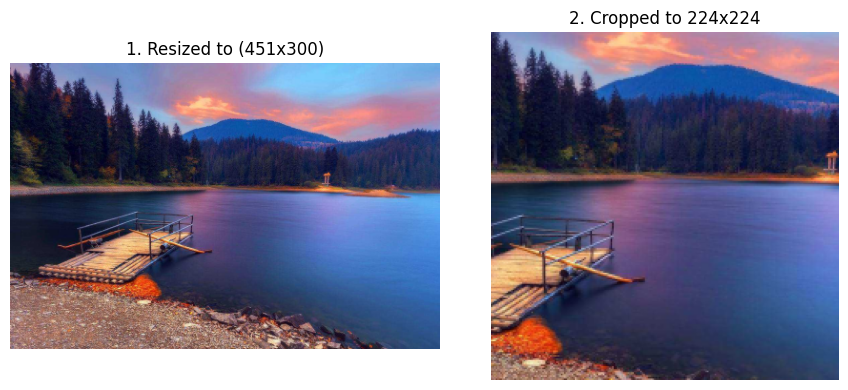

In [ ]:
# в) Робимо спочатку resize, а потім crop
h, w = img_bgr.shape[:2]

# 1. Пропорційно зменшуємо картинку
target_short_edge = 300
if h < w:
    new_h = target_short_edge
    new_w = int(w * (target_short_edge / h))
else:
    new_w = target_short_edge
    new_h = int(h * (target_short_edge / w))

img_resized_first = cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)

# 2. Тепер робимо Center Crop 224x224 вже зі зменшеної картинки
resized_h, resized_w = img_resized_first.shape[:2]
crop_size = 224
half = crop_size // 2

cy, cx = resized_h // 2, resized_w // 2
y1, y2 = cy - half, cy + half
x1, x2 = cx - half, cx + half

resized_img = img_resized_first[y1:y2, x1:x2]

# 3. Переведення у float32 та розрахунок пам'яті
img_float = resized_img.astype('float32')

mb_uint8 = resized_img.nbytes / (1024 * 1024)
mb_float32 = img_float.nbytes / (1024 * 1024)

print(f"Розмір uint8 (224x224x3):   {resized_img.nbytes} байт ({mb_uint8:.3f} MB)")
print(f"Розмір float32 (224x224x3): {img_float.nbytes} байт ({mb_float32:.3f} MB)")

# 4. Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].imshow(cv2.cvtColor(img_resized_first, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'1. Resized to ({new_w}x{new_h})')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(resized_img, cv2.COLOR_BGR2RGB))
axes[1].set_title('2. Cropped to 224x224')
axes[1].axis('off')

plt.tight_layout()
plt.show()

При правильному порядку дій (Resize $\rightarrow$ Crop) ми зберігаємо головні об'єкти на фото та отримуємо стандартний розмір $224 \times 224$, необхідний для нейромереж. Обсяг пам'яті для float32 у 4 рази більший, ніж для uint8 (0.57 MB проти 0.14 MB), оскільки кожен піксель займає 4 байти замість 1.

=== Пам'ять для 4K кадру (3840x2160x3) ===
uint8   :  24883200 байт (23.73 MB)
float32 :  99532800 байт (94.92 MB)


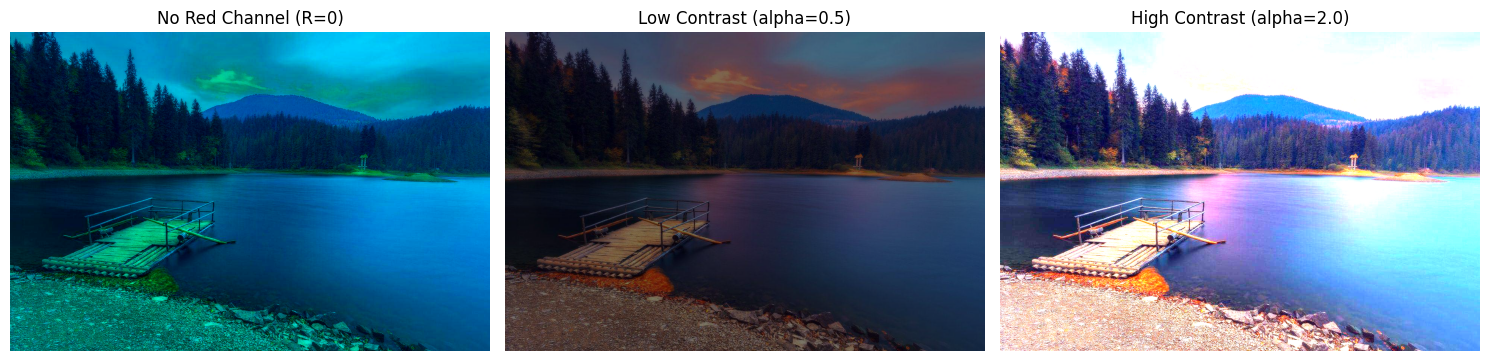

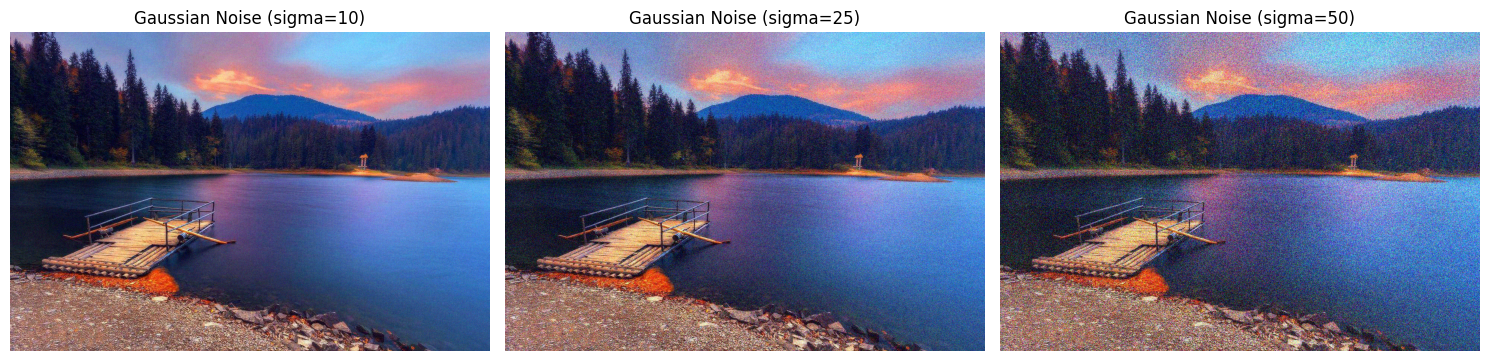

In [ ]:
# =============================================================================
# Додаткове завдання
# =============================================================================

# 1. Вимкнення одного каналу
img_no_red_col = img_bgr.copy()
img_no_red_col[:, :, 2] = 0


# 2. Зміна контрасту (convertScaleAbs)
img_low_alpha = cv2.convertScaleAbs(img_bgr, alpha=0.5, beta=0)
img_high_alpha = cv2.convertScaleAbs(img_bgr, alpha=2.0, beta=0)


# 3. Додавання гаусового шуму (сигма = 10, 25, 50)
def add_gauss_noise(img, sigma):
    noise = np.random.normal(0, sigma, img.shape)
    return np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

img_sigma_10 = add_gauss_noise(img_bgr, 10)
img_sigma_25 = add_gauss_noise(img_bgr, 25)
img_sigma_50 = add_gauss_noise(img_bgr, 50)


# 4. Розрахунок пам'яті для 4K кадру (3840 x 2160 x 3)
w_4k = 3840
h_4k = 2160
c_4k = 3

overall_4k = w_4k * h_4k * c_4k

uint8_4k = overall_4k
float32_4k = overall_4k * 4

uint8_4k_mb = uint8_4k / (1024 * 1024)
float32_4k_mb = float32_4k / (1024 * 1024)

print("=== Пам'ять для 4K кадру (3840x2160x3) ===")
print(f'uint8   :  {uint8_4k} байт ({uint8_4k_mb:.2f} MB)')
print(f'float32 :  {float32_4k} байт ({float32_4k_mb:.2f} MB)')


# 5. Візуалізація результатів
# Перша сітка: [Без червоного, Низький контраст, Високий контраст]
fig1, axes1 = plt.subplots(1, 3, figsize=(15, 4))

axes1[0].imshow(cv2.cvtColor(img_no_red_col, cv2.COLOR_BGR2RGB))
axes1[0].set_title('No Red Channel (R=0)')
axes1[0].axis('off')

axes1[1].imshow(cv2.cvtColor(img_low_alpha, cv2.COLOR_BGR2RGB))
axes1[1].set_title('Low Contrast (alpha=0.5)')
axes1[1].axis('off')

axes1[2].imshow(cv2.cvtColor(img_high_alpha, cv2.COLOR_BGR2RGB))
axes1[2].set_title('High Contrast (alpha=2.0)')
axes1[2].axis('off')

plt.tight_layout()
plt.show()

# Друга сітка: [Шум 10, Шум 25, Шум 50]
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))

axes2[0].imshow(cv2.cvtColor(img_sigma_10, cv2.COLOR_BGR2RGB))
axes2[0].set_title('Gaussian Noise (sigma=10)')
axes2[0].axis('off')

axes2[1].imshow(cv2.cvtColor(img_sigma_25, cv2.COLOR_BGR2RGB))
axes2[1].set_title('Gaussian Noise (sigma=25)')
axes2[1].axis('off')

axes2[2].imshow(cv2.cvtColor(img_sigma_50, cv2.COLOR_BGR2RGB))
axes2[2].set_title('Gaussian Noise (sigma=50)')
axes2[2].axis('off')

plt.tight_layout()
plt.show()

# Підсумки додаткової практики

### 1. Вимкнення червоного каналу (R = 0)
При обнуленні червоного каналу зображення набуває вираженого ціанового відтінку. Усі теплі кольори (червоний, жовтий, помаранчевий) повністю втрачаються, оскільки залишаються тільки синій та зелений канали.

### 2. Зміна контрасту (convertScaleAbs)
* **`alpha = 0.5` (зниження контрасту):** Зображення стає тьмяним та темним. Динамічний діапазон звужується, через що дрібні деталі в тінях та середніх тонах стають слабопомітними.
* **`alpha = 2.0` (підвищення контрасту):** Зображення стає занадто яскравим. Відбувається пересвітлення светлих ділянок (зокрема неба), через що деталі на хмарах повністю втрачаються, хоча контури вежі стають більш чіткими.

### 3. Додавання гаусового шуму (sigma = 10, 25, 50)
* **sigma = 10:** Шум майже незапомітний, усі дрібні деталі (металеві конструкції вежі, листя дерев, хмари) виразно розпізнаються.
* **sigma = 25:** З'являється помітна зернистість, але загальні контури та середні деталі об'єктів усе ще добре зчитуються.
* **sigma = 50:** Шум стає дуже сильним. Дрібні деталі та текстури втрачаються, проте силует та великі контрастні об'єкти все ще залишаються розпізнаваними.
* **Висновок:** Деталі впевнено розпізнаються при **sigma = 10** та **sigma = 25**.

### 4. Розрахунок пам'яті для 4K кадру (3840 x 2160 x 3)
* Загальна кількість елементів (піксельних значень): 3840 x 2160 x 3 = 24 883 200
* **uint8** (1 байт на елемент): 24 883 200 байт ≈ **23.73 MB**
* **float32** (4 байти на елемент): 99 532 800 байт ≈ **94.92 MB**
* **Висновок:** Конвертація кадру з uint8 у float32 збільшує необхідний обсяг оперативної пам'яті точно в **4 рази**.
